# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [107]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 14, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [108]:
df.dtypes

Age                   float64
Gender                    str
Income                    str
Education                 str
Marital Status            str
Number of Children      int64
Home Ownership            str
Credit Score              str
dtype: object

In [109]:
df['Age'] = df['Age'].astype('Int64')
df['Income'] = (
    df['Income']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype('float64'))


In [110]:
df.dtypes

Age                     Int64
Gender                    str
Income                float64
Education                 str
Marital Status            str
Number of Children      int64
Home Ownership            str
Credit Score              str
dtype: object

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [111]:
df.isnull().sum()

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64

In [112]:
porcentagem_nulos = (df.isnull().sum() / len(df)) * 100
print(porcentagem_nulos)

Age                   20.731707
Gender                 0.000000
Income                 0.000000
Education              0.000000
Marital Status         0.000000
Number of Children     0.000000
Home Ownership         0.000000
Credit Score           0.000000
dtype: float64


In [113]:
df['Age'] = df['Age'].fillna(round(df['Age'].mean()))

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [114]:
colunas_categoricas = df.select_dtypes(include=['object', 'string', 'str']).columns

for col in colunas_categoricas:
    valores_unicos = df[col].unique()
    print(f"Coluna: '{col}'")
    print(f"Valores encontrados: {valores_unicos}")
    print("-" * 50)

Coluna: 'Gender'
Valores encontrados: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
Coluna: 'Education'
Valores encontrados: <StringArray>
[  'Bachelor's Degree',     'Master's Degree',           'Doctorate',
 'High School Diploma',  'Associate's Degree']
Length: 5, dtype: str
--------------------------------------------------
Coluna: 'Marital Status'
Valores encontrados: <StringArray>
['Single', 'Married']
Length: 2, dtype: str
--------------------------------------------------
Coluna: 'Home Ownership'
Valores encontrados: <StringArray>
['Rented', 'Owned']
Length: 2, dtype: str
--------------------------------------------------
Coluna: 'Credit Score'
Valores encontrados: <StringArray>
['High', 'Average', 'Low']
Length: 3, dtype: str
--------------------------------------------------


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [115]:
df.describe()

,Age,Income,Number of Children
count,164.0,164.000000,164.000000
mean,37.609756,83765.243902,0.652439
std,7.564457,32457.306728,0.883346
min,25.0,25000.000000,0.000000
25%,31.75,57500.000000,0.000000
50%,38.0,83750.000000,0.000000
75%,43.0,105000.000000,1.000000
max,53.0,162500.000000,3.000000


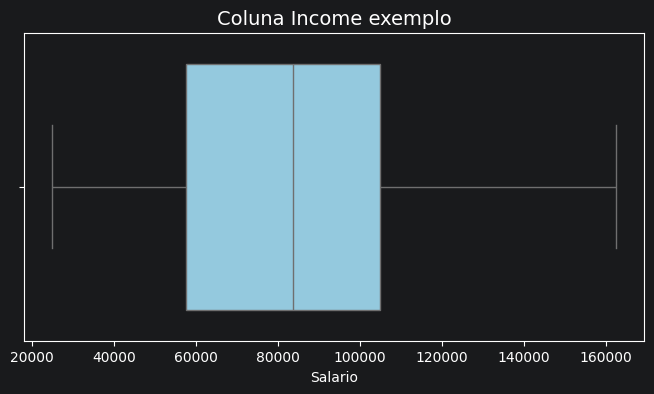

'Percebesse que nao possui outliers na variavel Income, logo nao havera necessidade de tratamento. Pode se perceber que nas outras varias tambem nao precisa\npois a media e a mediana aprensetam valores proximos'

In [116]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x='Income', color='skyblue')
plt.title('Coluna Income exemplo', fontsize=14)
plt.xlabel('Salario')
plt.show()

"""Percebesse que nao possui outliers na variavel Income, logo nao havera necessidade de tratamento. Pode se perceber que nas outras varias tambem nao precisa
pois a media e a mediana aprensetam valores proximos"""

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

In [117]:
colunas_categoricas = df.select_dtypes(include=['object', 'string', 'str']).columns
for col in colunas_categoricas:
    print(df[col].value_counts(normalize=True) * 100)

Gender
Female    52.439024
Male      47.560976
Name: proportion, dtype: float64
Education
Bachelor's Degree      25.609756
Master's Degree        21.951220
Doctorate              18.902439
High School Diploma    18.292683
Associate's Degree     15.243902
Name: proportion, dtype: float64
Marital Status
Married    53.04878
Single     46.95122
Name: proportion, dtype: float64
Home Ownership
Owned     67.682927
Rented    32.317073
Name: proportion, dtype: float64
Credit Score
High       68.902439
Average    21.951220
Low         9.146341
Name: proportion, dtype: float64


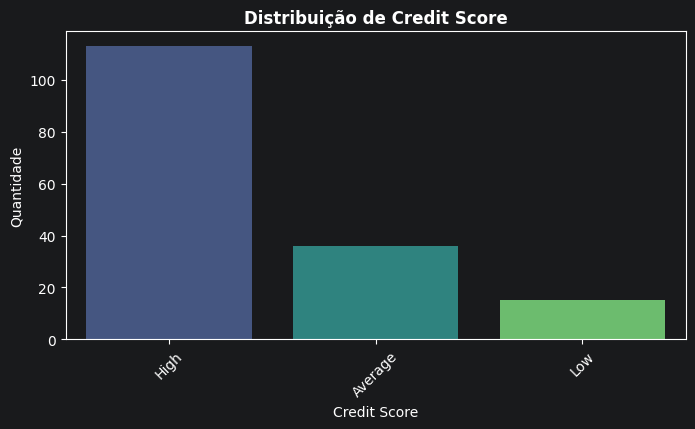

In [118]:
plt.figure(figsize=(8, 4))
sns.countplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        order=df[col].value_counts().index,
        palette='viridis'
    )
plt.title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
plt.xlabel(col)
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [119]:
#seu código aqui

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



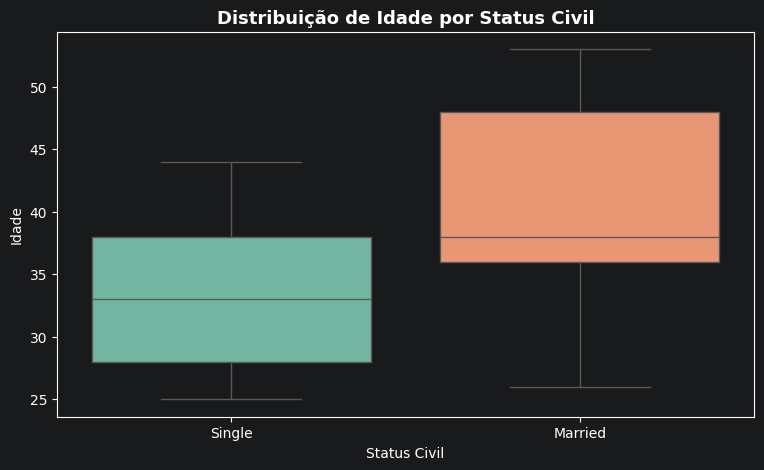

In [120]:
#1
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='Marital Status',
    y='Age',
    hue='Marital Status',
    legend=False,
    palette='Set2'
)
plt.title('Distribuição de Idade por Status Civil', fontsize=13, fontweight='bold')
plt.xlabel('Status Civil')
plt.ylabel('Idade')
plt.show()

In [121]:
df.dtypes

Age                     Int64
Gender                    str
Income                float64
Education                 str
Marital Status            str
Number of Children      int64
Home Ownership            str
Credit Score              str
dtype: object

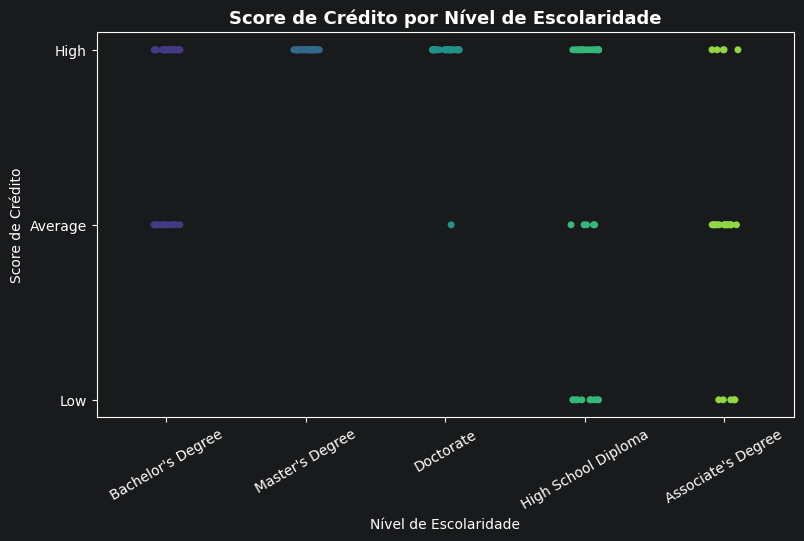

In [122]:
#2
plt.figure(figsize=(9, 5))
ordem_escolaridade = df['Education'].value_counts().index

sns.stripplot(
    data=df,
    x='Education',
    y='Credit Score',
    hue='Education',
    legend=False,
    order=ordem_escolaridade,
    palette='viridis'
)
plt.title('Score de Crédito por Nível de Escolaridade', fontsize=13, fontweight='bold')
plt.xlabel('Nível de Escolaridade')
plt.ylabel('Score de Crédito')
plt.xticks(rotation=30)
plt.show()

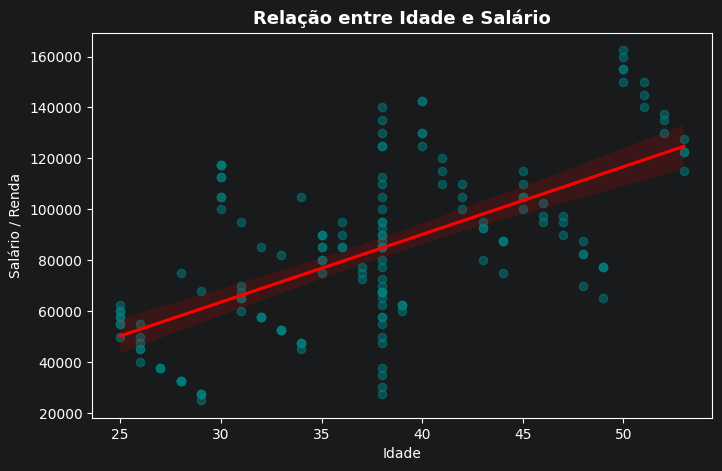

'Ao analisarmos o gráfico de dispersão, a linha vermelha de tendência nos indica a direção da correlação. Se a linha for ligeiramente ascendente, conclui-se que o salário tende a aumentar conforme o cliente envelhece (refletindo consolidação de carreira e tempo de mercado). Se os pontos estiverem dispersos de forma caótica e a linha estiver horizontal, a idade não exerce influência direta sobre a faixa salarial na amostra analisada.'

In [123]:
#3
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='Age',
    y='Income',
    scatter_kws={'alpha':0.5, 'color': 'teal'},
    line_kws={'color': 'red'}
)
plt.title('Relação entre Idade e Salário', fontsize=13, fontweight='bold')
plt.xlabel('Idade')
plt.ylabel('Salário / Renda')
plt.show()
"""Ao analisarmos o gráfico de dispersão, a linha vermelha de tendência nos indica a direção da correlação. Se a linha for ligeiramente ascendente, conclui-se que o salário tende a aumentar conforme o cliente envelhece (refletindo consolidação de carreira e tempo de mercado). Se os pontos estiverem dispersos de forma caótica e a linha estiver horizontal, a idade não exerce influência direta sobre a faixa salarial na amostra analisada."""

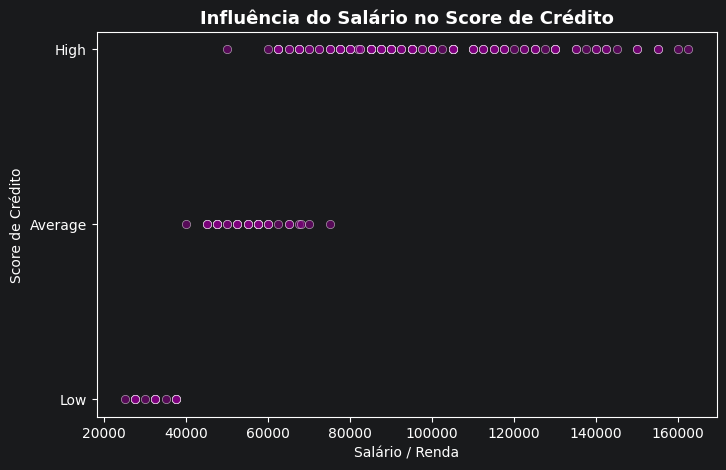

In [124]:
#4
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Income',
    y='Credit Score',
    alpha=0.6,
    color='purple'
)
plt.title('Influência do Salário no Score de Crédito', fontsize=13, fontweight='bold')
plt.xlabel('Salário / Renda')
plt.ylabel('Score de Crédito')
plt.show()

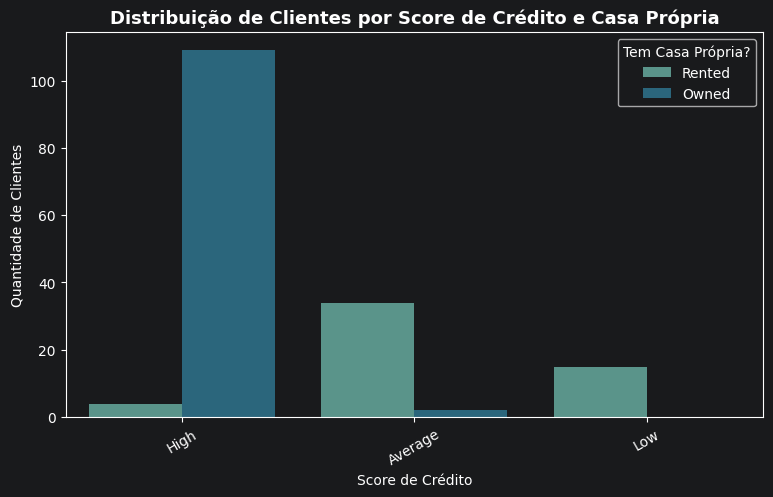

In [125]:
#5
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x='Credit Score',
    hue='Home Ownership',
    palette='crest',

)
plt.title('Distribuição de Clientes por Score de Crédito e Casa Própria', fontsize=13, fontweight='bold')
plt.xlabel('Score de Crédito')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Tem Casa Própria?')
plt.xticks(rotation=30) # Rotaciona os nomes se forem longos
plt.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

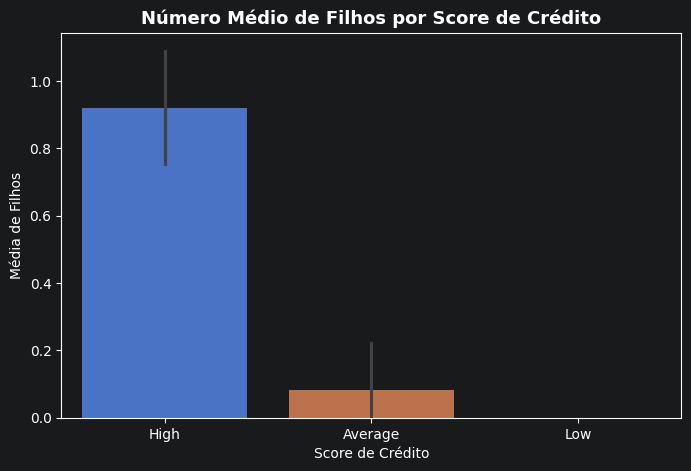

In [126]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x='Credit Score',        # O Score de Crédito (Texto) DEVE ficar no eixo X
    y='Number of Children',  # O Número de Filhos (Número) DEVE ficar no eixo Y
    hue='Credit Score',
    legend=False
)

plt.title('Número Médio de Filhos por Score de Crédito', fontsize=13, fontweight='bold')
plt.xlabel('Score de Crédito')
plt.ylabel('Média de Filhos')
plt.show()


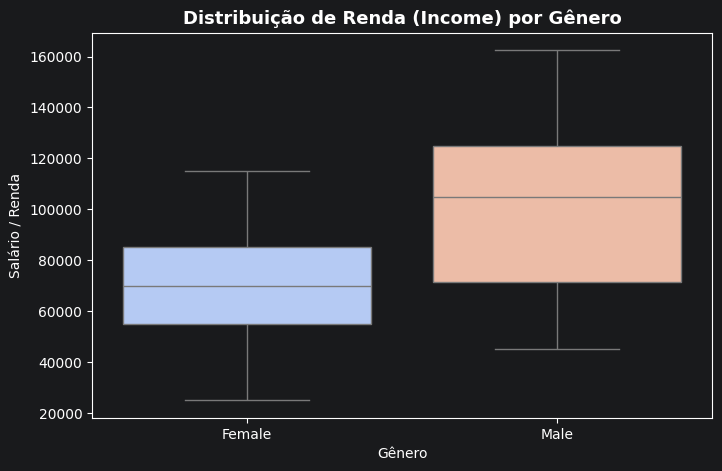

In [127]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='Income', hue='Gender', palette='coolwarm')
plt.title('Distribuição de Renda (Income) por Gênero', fontsize=13, fontweight='bold')
plt.xlabel('Gênero')
plt.ylabel('Salário / Renda')
plt.savefig('renda_por_genero.png', dpi=300, bbox_inches='tight')
plt.show()

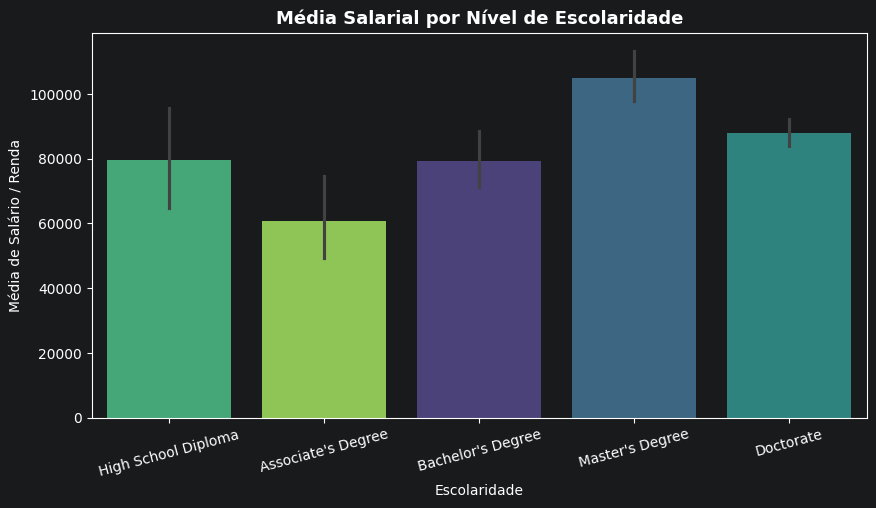

In [128]:
edu_order = ["High School Diploma", "Associate's Degree", "Bachelor's Degree", "Master's Degree", "Doctorate"]
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Education',
    y='Income',
    hue='Education',
    order=[e for e in edu_order if e in df['Education'].unique()],
    palette='viridis'
)
plt.title('Média Salarial por Nível de Escolaridade', fontsize=13, fontweight='bold')
plt.xlabel('Escolaridade')
plt.ylabel('Média de Salário / Renda')
plt.xticks(rotation=15)
plt.savefig('escolaridade_vs_renda.png', dpi=300, bbox_inches='tight')
plt.show()

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

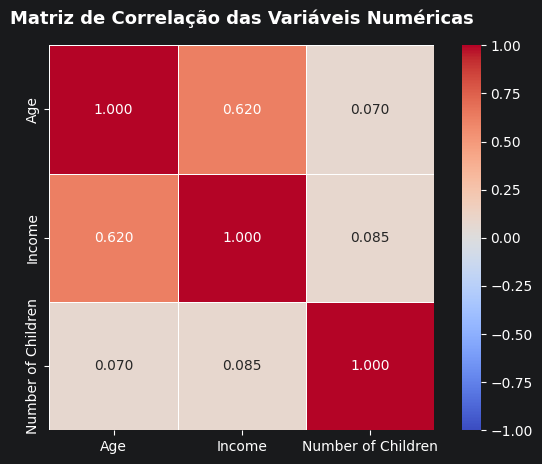

In [129]:
colunas_numericas = df[['Age', 'Income', 'Number of Children']]
matriz_corr = colunas_numericas.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=13, fontweight='bold', pad=15)
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [130]:
#Sim, foi encontrada uma relação de média para alta correlação na base de dados. Sim, faz total sentido prático e econômico.

"""O número de filhos apresentou correlação quase nula com a Idade (0.078) e com a Renda (0.085), o que também faz sentido, dado que a decisão de ter filhos e a quantidade deles envolvem fatores socioculturais e pessoais muito mais complexos do que apenas a faixa de idade ou o salário atual do indivíduo."""

'O número de filhos apresentou correlação quase nula com a Idade (0.078) e com a Renda (0.085), o que também faz sentido, dado que a decisão de ter filhos e a quantidade deles envolvem fatores socioculturais e pessoais muito mais complexos do que apenas a faixa de idade ou o salário atual do indivíduo.'

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [133]:
df['Income'] = df['Income'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

df_encoded = df.copy()

le = LabelEncoder()

colunas_binarias = ['Gender', 'Marital Status', 'Home Ownership']
for col in colunas_binarias:
    df_encoded[f'{col}_Encoded'] = le.fit_transform(df_encoded[col])

score_map = {'Low': 0, 'Average': 1, 'High': 2}
df_encoded['Credit_Score_Encoded'] = df_encoded['Credit Score'].map(score_map)

df_encoded = pd.get_dummies(df_encoded, columns=['Education'], prefix='Edu', dtype=int)

colunas_originais_para_excluir = ['Gender', 'Marital Status', 'Home Ownership', 'Credit Score']
df_encoded.drop(columns=colunas_originais_para_excluir, inplace=True)
print("Novas colunas na base tratada:")
print(df_encoded.columns.tolist())
df_encoded.head()

Novas colunas na base tratada:
['Age', 'Income', 'Number of Children', 'Gender_Encoded', 'Marital Status_Encoded', 'Home Ownership_Encoded', 'Credit_Score_Encoded', "Edu_Associate's Degree", "Edu_Bachelor's Degree", 'Edu_Doctorate', 'Edu_High School Diploma', "Edu_Master's Degree"]


,Age,Income,Number of Children,Gender_Encoded,Marital Status_Encoded,Home Ownership_Encoded,Credit_Score_Encoded,Edu_Associate's Degree,Edu_Bachelor's Degree,Edu_Doctorate,Edu_High School Diploma,Edu_Master's Degree
0,25,5000000.0,0,0,1,1,2,0,1,0,0,0
1,30,10000000.0,2,1,0,0,2,0,0,0,0,1
2,35,7500000.0,1,0,0,0,2,0,0,1,0,0
3,40,12500000.0,0,1,1,0,2,0,0,0,1,0
4,45,10000000.0,3,0,0,0,2,0,1,0,0,0


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

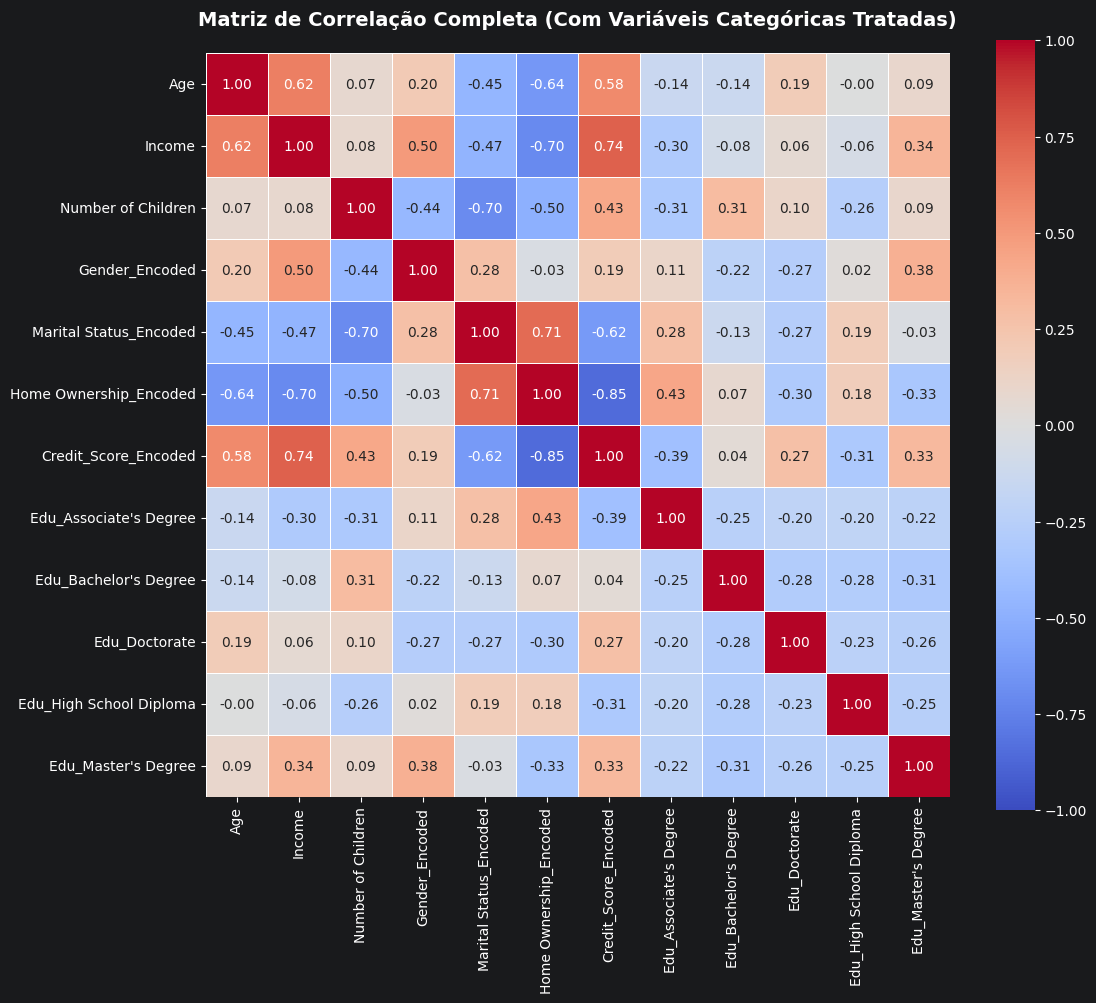

In [134]:
full_corr = df_encoded.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    full_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)

plt.title('Matriz de Correlação Completa (Com Variáveis Categóricas Tratadas)', fontsize=14, fontweight='bold', pad=20)
plt.show()

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [136]:
y = df_encoded['Credit_Score_Encoded']
X = df_encoded.drop(columns=['Credit_Score_Encoded'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train (Atributos de Treino): {X_train.shape}")
print(f"X_test  (Atributos de Teste):  {X_test.shape}")
print(f"y_train (Rótulos de Treino):   {y_train.shape}")
print(f"y_test  (Rótulos de Teste):    {y_test.shape}")

X_train (Atributos de Treino): (131, 11)
X_test  (Atributos de Teste):  (33, 11)
y_train (Rótulos de Treino):   (131,)
y_test  (Rótulos de Teste):    (33,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

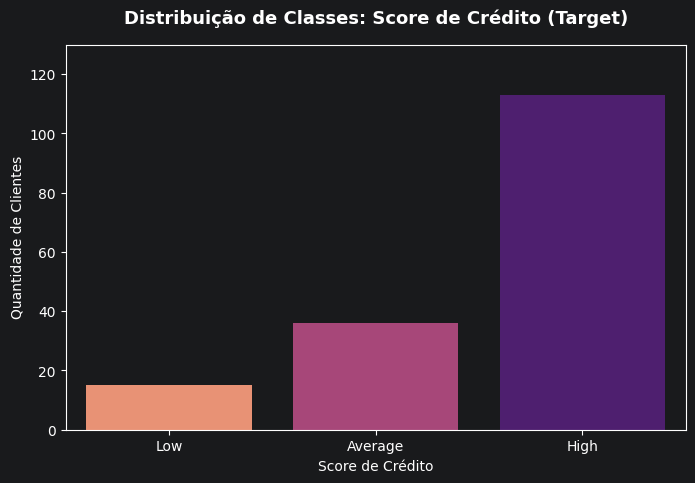

In [137]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Credit Score',
    order=['Low', 'Average', 'High'],
    hue='Credit Score',
    palette='magma'
)

plt.title('Distribuição de Classes: Score de Crédito (Target)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Score de Crédito')
plt.ylabel('Quantidade de Clientes')
plt.ylim(0, df['Credit Score'].value_counts().max() * 1.15)
plt.show()

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [139]:
age_median = X_train['Age'].median()

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean['Age'] = X_train_clean['Age'].fillna(age_median)
X_test_clean['Age'] = X_test_clean['Age'].fillna(age_median)

df_train_temp = X_train_clean.copy()
df_train_temp['Credit_Score_Encoded'] = y_train

class_counts = df_train_temp['Credit_Score_Encoded'].value_counts()
max_class_count = class_counts.max()


df_low = df_train_temp[df_train_temp['Credit_Score_Encoded'] == 0]
df_average = df_train_temp[df_train_temp['Credit_Score_Encoded'] == 1]
df_high = df_train_temp[df_train_temp['Credit_Score_Encoded'] == 2]

df_low_balanced = df_low.sample(max_class_count, replace=True, random_state=42)
df_average_balanced = df_average.sample(max_class_count, replace=True, random_state=42)

df_train_balanced = pd.concat([df_high, df_average_balanced, df_low_balanced], axis=0)

X_train_bal = df_train_balanced.drop(columns=['Credit_Score_Encoded'])
y_train_bal = df_train_balanced['Credit_Score_Encoded']

print("==================================================")
print("       VERIFICAÇÃO DE BALANCEAMENTO (TREINO)      ")
print("==================================================")
print("Antes do Balanceamento:")
print(y_train.value_counts().rename({2: 'High (2)', 1: 'Average (1)', 0: 'Low (0)'}))
print("\nDepois do Balanceamento:")
print(y_train_bal.value_counts().rename({2: 'High (2)', 1: 'Average (1)', 0: 'Low (0)'}))

       VERIFICAÇÃO DE BALANCEAMENTO (TREINO)      
Antes do Balanceamento:
Credit_Score_Encoded
High (2)       90
Average (1)    31
Low (0)        10
Name: count, dtype: int64

Depois do Balanceamento:
Credit_Score_Encoded
High (2)       90
Average (1)    90
Low (0)        90
Name: count, dtype: int64
